# Análisis Biológico de Factores MOFA

Caracterización biológica de los factores mediante:
- **PROGENy**: vías de señalización (ULM)
- **Hallmarks (MSigDB)**: procesos biológicos (ORA sobre top 100 genes)
- **Covariates**: asociación con drug, moa-fine, plate y concentration (ANOVA + FDR)

Por cada factor se genera una tabla resumen con:
- Top 10 genes positivos y negativos (por peso)
- Top 5 vías PROGENy positivas y negativas
- Top 5 Hallmarks ORA positivos y negativos
- Estadístico F y p-value (con corrección FDR) por covariate


In [1]:
import anndata as ad
import decoupler as dc
import mofax as mfx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests



# --- Matriz de anotaciones ---
def get_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''
    
PATH_OUT = '/home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/'

In [4]:
# --- Rutas ---
PATH_ADATA = "/home/miguel-agromayor-otero/Escritorio/TFM_datos/mofa_adata_30f.h5ad"
PATH_OUT_GRAF = "/home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/"
# --- Cargar datos ---
adata = ad.read(PATH_ADATA)
pesos = pd.DataFrame(
    adata.uns['mofa_weights'],
    index=adata.uns['mofa_weights_genes'],
    columns=adata.uns['mofa_weights_factors']
)

pesos_t = pesos.T 
factor_order = sorted(pesos_t.index, key=lambda x: int(x.replace("Factor", "")))
pesos_t

/home/miguel-agromayor-otero/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


,TSPAN6,DPM1,SCYL3,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,LAS1L,...,KRTAP4-3,CT45A5,OR1G1,PTF1A,OR5AP2,OR8B4,OR2A4,IFNA4,AMY1A,LGALS7
Factor1,0.003181,0.001737,-0.019170,0.007619,0.003189,-0.000803,-0.011724,-0.000867,-0.002446,-0.001176,...,0.009350,0.011362,0.000035,0.013264,0.000581,0.008204,0.035254,0.007920,0.011555,1.192233e-02
Factor2,0.036527,-0.039974,-0.002799,-0.017942,0.026326,-0.038185,-0.052244,-0.004353,0.032729,-0.029260,...,0.001714,0.002332,0.000207,0.005989,0.000049,0.002614,0.012736,0.000676,0.001041,3.435102e-03
Factor3,0.003018,-0.018305,0.007036,-0.059763,-0.003035,-0.003405,0.049810,-0.013930,-0.020055,0.036670,...,-0.000397,0.004346,-0.000245,0.001558,-0.000249,-0.000219,0.003050,-0.000168,0.000681,3.707185e-03
Factor4,0.061698,-0.098461,-0.005841,0.036645,-0.003111,-0.030831,-0.096607,0.027326,0.082100,0.047765,...,-0.000689,-0.001847,-0.000218,-0.005762,-0.000225,-0.001685,-0.005702,-0.003321,-0.002824,-5.259971e-04
Factor5,-0.019388,-0.021879,0.057306,0.021822,-0.045735,0.009921,-0.033298,0.033179,0.039740,-0.033334,...,-0.000376,0.003607,-0.000217,0.005030,0.000304,0.000268,0.010060,0.000860,0.004813,4.271849e-03
Factor6,0.005176,0.114926,-0.051664,-0.090648,-0.063759,0.046317,0.068441,0.074602,0.183034,-0.017874,...,-0.001547,-0.004468,0.000428,-0.000746,-0.000168,-0.000245,-0.006732,0.000134,-0.001479,5.827582e-04
Factor7,0.088426,-0.056532,0.004001,0.072125,0.032925,0.002697,-0.068910,0.007909,0.011227,-0.057601,...,-0.004936,-0.002853,0.000345,-0.002023,-0.000603,-0.001324,-0.008040,-0.001952,-0.003110,-3.072836e-04
Factor8,0.019549,-0.014539,-0.015538,-0.062623,0.000880,-0.025434,-0.036099,-0.001435,-0.016330,-0.025474,...,-0.000123,-0.001926,-0.000088,0.001228,-0.000448,-0.000113,0.003914,0.000525,0.002107,1.327557e-03
Factor9,0.016933,0.009057,-0.055652,-0.026840,-0.021138,-0.018050,0.010259,0.042116,0.021495,-0.149607,...,-0.001803,-0.003767,0.000023,-0.000816,-0.000554,-0.001432,-0.001477,-0.000067,-0.000886,-2.448774e-04
Factor10,-0.114156,-0.022109,-0.011158,0.012351,-0.203495,-0.038264,0.017399,-0.012760,0.004181,-0.086255,...,0.000882,-0.002010,0.000237,-0.000685,-0.000701,0.001656,-0.000953,-0.001698,-0.000963,-1.605303e-03


## TOP 10 genes por Factor

In [5]:
resultados_genes = []

for factor in factor_order:
    pesos_factor   = pesos_t.loc[factor].sort_values(ascending=False)
    top_10_pos     = pesos_factor.head(10)
    top_10_neg     = pesos_factor.tail(10).sort_values(ascending=True)

    resultados_genes.append({
        "Factor":          factor,
        "Top 10 Genes (+)": ", ".join(f"{g} ({v:.2f})" for g, v in zip(top_10_pos.index, top_10_pos.values)),
        "Top 10 Genes (-)": ", ".join(f"{g} ({v:.2f})" for g, v in zip(top_10_neg.index, top_10_neg.values)),
    })

df_genes = pd.DataFrame(resultados_genes)
print(df_genes)

      Factor                                   Top 10 Genes (+)  \
0    Factor1  SELE (0.10), FRMD7 (0.10), APOC3 (0.09), MGAT4...   
1    Factor2  RNASE4 (0.20), IFITM1 (0.20), IFITM2 (0.16), I...   
2    Factor3  POLGARF (0.21), RPL18A (0.18), PLEC (0.17), H4...   
3    Factor4  PLEC (0.25), H2AC12 (0.24), DBN1 (0.24), LRRC4...   
4    Factor5  TMEM232 (0.13), EFCAB6 (0.13), BBS9 (0.12), CF...   
5    Factor6  MT1X (0.36), GPC2 (0.34), SAA1 (0.34), CYP46A1...   
6    Factor7  CEBPD (0.29), ISG15 (0.28), CITED2 (0.26), IFI...   
7    Factor8  EGR1 (0.38), SPRY4 (0.35), DUSP6 (0.31), H2AC2...   
8    Factor9  MT-ND4L (0.76), MT-ND1 (0.61), ZBED6 (0.57), M...   
9   Factor10  EGR1 (0.74), EGR2 (0.60), DUSP6 (0.58), EGR3 (...   
10  Factor11  H1-4 (0.67), H1-2 (0.49), H1-3 (0.47), H2AC20 ...   
11  Factor12  MT-ND6 (0.32), FSCN2 (0.30), CCDC9 (0.25), BTB...   
12  Factor13  TRIB3 (0.30), TUBE1 (0.29), NIBAN1 (0.29), ANK...   
13  Factor14  FKBP5 (0.84), ZBTB16 (0.72), SAA1 (0.59), TSC2..

## PROGENy — Vías de Señalización (ULM). Obtención de las 5 vías significativas top 5 positivas y top 5 negativas.

Actividades PROGENy: (30, 14)


/tmp/ipykernel_384372/1473178824.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = padj_progeny.applymap(get_stars)


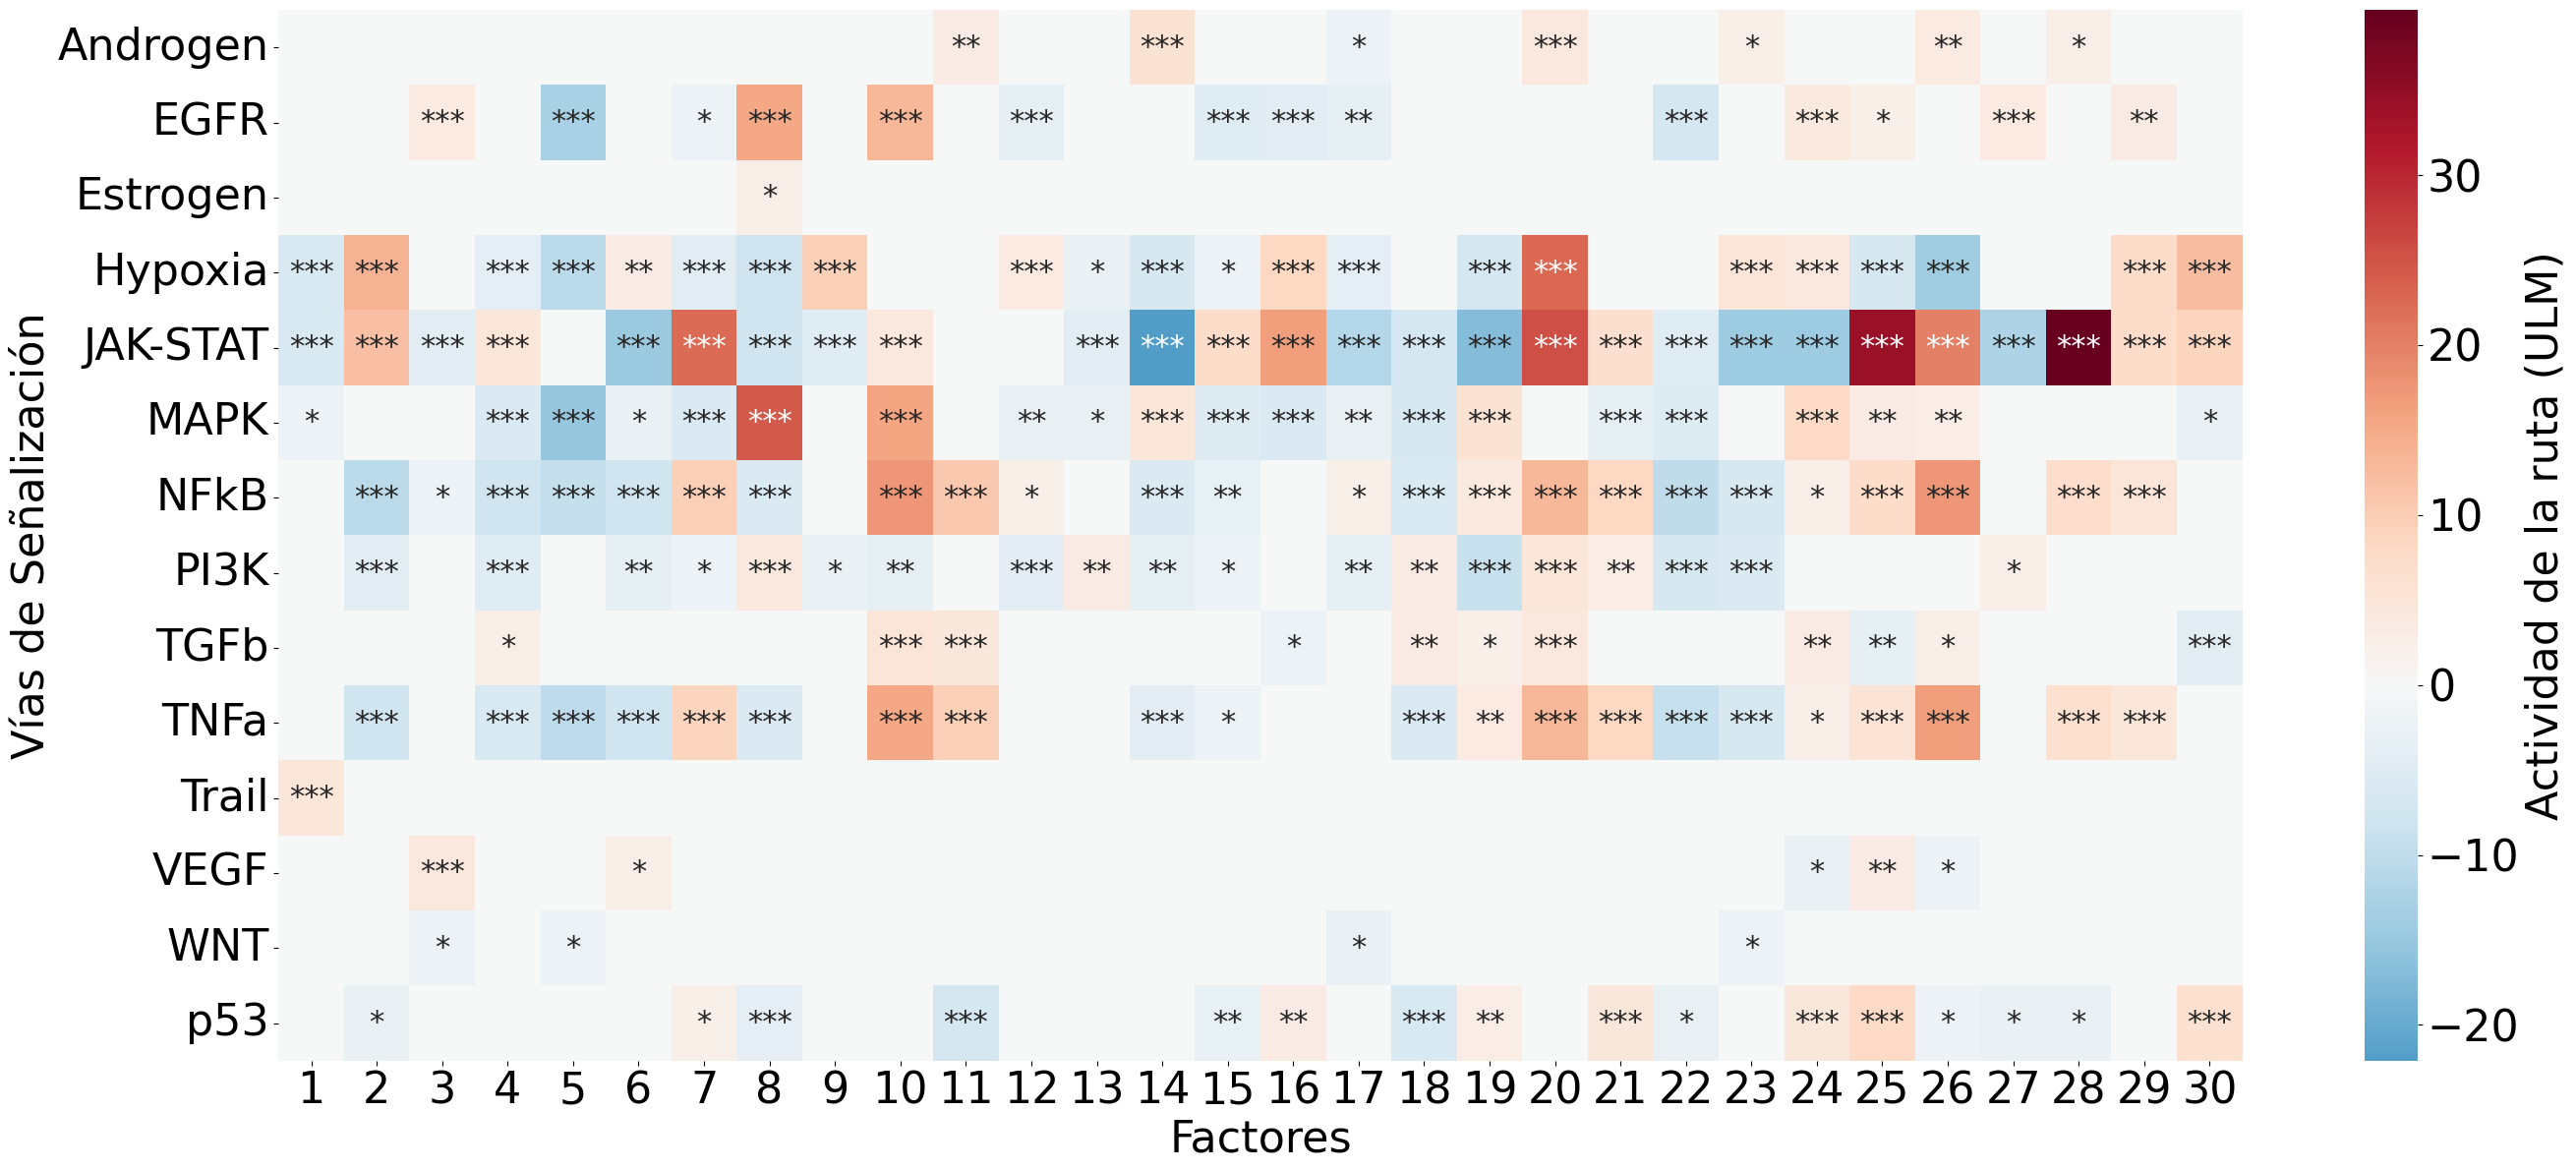

      Factor                                  PROGENy Top 5 (+)  \
0    Factor1                                       Trail (4.81)   
1    Factor2                  Hypoxia (13.79), JAK-STAT (11.85)   
2    Factor3                           VEGF (4.14), EGFR (3.62)   
3    Factor4                       JAK-STAT (4.93), TGFb (2.75)   
4    Factor5                                                      
5    Factor6                        Hypoxia (3.47), VEGF (2.60)   
6    Factor7  JAK-STAT (22.51), NFkB (9.41), TNFa (8.68), p5...   
7    Factor8  MAPK (24.39), EGFR (15.54), PI3K (4.10), Estro...   
8    Factor9                                     Hypoxia (9.36)   
9   Factor10  NFkB (17.36), MAPK (15.69), TNFa (15.36), EGFR...   
10  Factor11  NFkB (10.68), TNFa (9.48), TGFb (4.70), Androg...   
11  Factor12                        Hypoxia (3.74), NFkB (2.52)   
12  Factor13                                        PI3K (3.30)   
13  Factor14                       Androgen (5.90), MAPK (4.86

In [6]:
from statsmodels.stats.multitest import multipletests
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calcular actividades y p-valores con PROGENy ---
progeny = dc.get_progeny(organism='human')
acts_progeny, pvals_progeny = dc.run_ulm(mat=pesos_t, net=progeny)
print(f"Actividades PROGENy: {acts_progeny.shape}")

# --- 2. Corrección BH GLOBAL sobre toda la matriz (única fuente de verdad) ---
shape = pvals_progeny.shape
padj_flat = multipletests(pvals_progeny.values.flatten(), method='fdr_bh')[1]
padj_progeny = pd.DataFrame(
    padj_flat.reshape(shape),
    index=pvals_progeny.index,
    columns=pvals_progeny.columns
)

# --- 3. Heatmap: enmascarar no significativos y generar matriz de asteriscos ---
acts_progeny_sig = acts_progeny.copy()
acts_progeny_sig[padj_progeny > 0.05] = 0
annot_matrix = padj_progeny.applymap(get_stars)

# limpiar etiquetas de factor para el heatmap
acts_progeny_sig_plot = acts_progeny_sig.rename(index=lambda f: str(f).replace("Factor", "").strip())
annot_matrix_plot     = annot_matrix.rename(index=lambda f: str(f).replace("Factor", "").strip())

fig, ax = plt.subplots(figsize=(28, 12))
sns.heatmap(
    acts_progeny_sig_plot.T,
    cmap='RdBu_r', center=0,
    annot=annot_matrix_plot.T,
    annot_kws={"size": 22},
    fmt='',
    yticklabels=True,
    cbar_kws={'label': 'Actividad de la ruta (ULM)'},
    ax=ax
)
ax.tick_params(axis='x', labelsize=32, rotation=0)
ax.tick_params(axis='y', labelsize=32, rotation=0)
cbar = ax.collections[0].colorbar
cbar.set_label('Actividad de la ruta (ULM)', size=32)
cbar.ax.tick_params(labelsize=32)
ax.set_xlabel("Factores", fontsize=32)
ax.set_ylabel("Vías de Señalización", fontsize=32)
plt.tight_layout()
plt.savefig(PATH_OUT + "heatmap_progeny.pdf", format="pdf", bbox_inches="tight")
plt.show()

# --- 4. Tabla resumen top-5 por factor, REUTILIZANDO el padj global (ya no se recalcula) ---
resultados_progeny = []
for factor in factor_order:
    scores = acts_progeny.loc[factor]
    padj_factor = padj_progeny.loc[factor]  # <- mismo padj global usado en el heatmap
    mask = padj_factor < 0.05
    scores_sig = scores[mask]
    scores_pos = scores_sig[scores_sig > 0].sort_values(ascending=False).head(5)
    scores_neg = scores_sig[scores_sig < 0].sort_values(ascending=True).head(5)

    resultados_progeny.append({
        "Factor": factor,
        "PROGENy Top 5 (+)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_pos.index, scores_pos.values)),
        "PROGENy Top 5 (-)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_neg.index, scores_neg.values)),
    })

df_resumen_progeny = pd.DataFrame(resultados_progeny)
print(df_resumen_progeny)

In [7]:
msigdb    = dc.get_resource('MSigDB')
hallmarks = msigdb[msigdb['collection'] == 'hallmark'].drop_duplicates(subset=['geneset', 'genesymbol'])
# Matrices binarizadas: 1 = gen en top 100 para ese factor
mat_pos = pd.DataFrame(0, index=pesos_t.index, columns=pesos_t.columns)
mat_neg = pd.DataFrame(0, index=pesos_t.index, columns=pesos_t.columns)
for factor in pesos_t.index:
    mat_pos.loc[factor, pesos_t.loc[factor].nlargest(100).index]  = 1
    mat_neg.loc[factor, pesos_t.loc[factor].nsmallest(100).index] = 1

acts_ora_pos, pvals_ora_pos = dc.run_ora(mat=mat_pos, net=hallmarks, source='geneset', target='genesymbol')
acts_ora_neg, pvals_ora_neg = dc.run_ora(mat=mat_neg, net=hallmarks, source='geneset', target='genesymbol')

mat_pos_sig  = pd.DataFrame(float('nan'), index=factor_order, columns=acts_ora_pos.columns)
mat_neg_sig  = pd.DataFrame(float('nan'), index=factor_order, columns=acts_ora_neg.columns)
mat_pos_padj = pd.DataFrame(float('nan'), index=factor_order, columns=acts_ora_pos.columns)
mat_neg_padj = pd.DataFrame(float('nan'), index=factor_order, columns=acts_ora_neg.columns)

resultados_ora = []
for factor in factor_order:
    # --- Scores positivos significativos ---
    scores_pos = acts_ora_pos.loc[factor]
    pvals_pos = pvals_ora_pos.loc[factor]
    padj_pos = pd.Series(
        multipletests(pvals_pos, method="fdr_bh")[1],
        index=pvals_pos.index
    )
    mask_pos = padj_pos < 0.05
    scores_sig_pos = scores_pos[mask_pos]

    # --- Scores negativos significativos ---
    scores_neg = acts_ora_neg.loc[factor]
    pvals_neg = pvals_ora_neg.loc[factor]
    padj_neg = pd.Series(
        multipletests(pvals_neg, method="fdr_bh")[1],
        index=pvals_neg.index
    )
    mask_neg = padj_neg < 0.05
    scores_sig_neg = scores_neg[mask_neg]

    scores_pos = scores_sig_pos.sort_values(ascending=False).head(5)
    scores_neg = scores_sig_neg.sort_values(ascending=False).head(5)

    # Matrices para heatmap (scores) y para asteriscos (padj)
    mat_pos_sig.loc[factor, scores_pos.index]  = scores_pos.values
    mat_neg_sig.loc[factor, scores_neg.index]  = scores_neg.values
    mat_pos_padj.loc[factor, scores_pos.index] = padj_pos[scores_pos.index].values
    mat_neg_padj.loc[factor, scores_neg.index] = padj_neg[scores_neg.index].values

    resultados_ora.append({
        "Factor":                  factor,
        "Hallmarks ORA Top 5 (+)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_pos.index, scores_pos.values)),
        "Hallmarks ORA Top 5 (-)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_neg.index, scores_neg.values)),
    })

df_hallmarks_ora = pd.DataFrame(resultados_ora)
print(df_hallmarks_ora)

      Factor                            Hallmarks ORA Top 5 (+)  \
0    Factor1  HALLMARK_COAGULATION (4.04), HALLMARK_MYOGENES...   
1    Factor2  HALLMARK_GLYCOLYSIS (11.19), HALLMARK_HYPOXIA ...   
2    Factor3  HALLMARK_MITOTIC_SPINDLE (4.58), HALLMARK_UNFO...   
3    Factor4                                                      
4    Factor5  HALLMARK_BILE_ACID_METABOLISM (4.13), HALLMARK...   
5    Factor6  HALLMARK_ADIPOGENESIS (5.53), HALLMARK_OXIDATI...   
6    Factor7  HALLMARK_INTERFERON_GAMMA_RESPONSE (42.04), HA...   
7    Factor8  HALLMARK_KRAS_SIGNALING_UP (15.61), HALLMARK_T...   
8    Factor9  HALLMARK_HYPOXIA (6.64), HALLMARK_MYOGENESIS (...   
9   Factor10  HALLMARK_TNFA_SIGNALING_VIA_NFKB (44.58), HALL...   
10  Factor11  HALLMARK_TNFA_SIGNALING_VIA_NFKB (29.14), HALL...   
11  Factor12  HALLMARK_E2F_TARGETS (12.75), HALLMARK_MYC_TAR...   
12  Factor13  HALLMARK_DNA_REPAIR (6.66), HALLMARK_MTORC1_SI...   
13  Factor14  HALLMARK_TNFA_SIGNALING_VIA_NFKB (8.45), HALLM..

/tmp/ipykernel_384372/2452407215.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pos = padj_plot.applymap(get_stars)


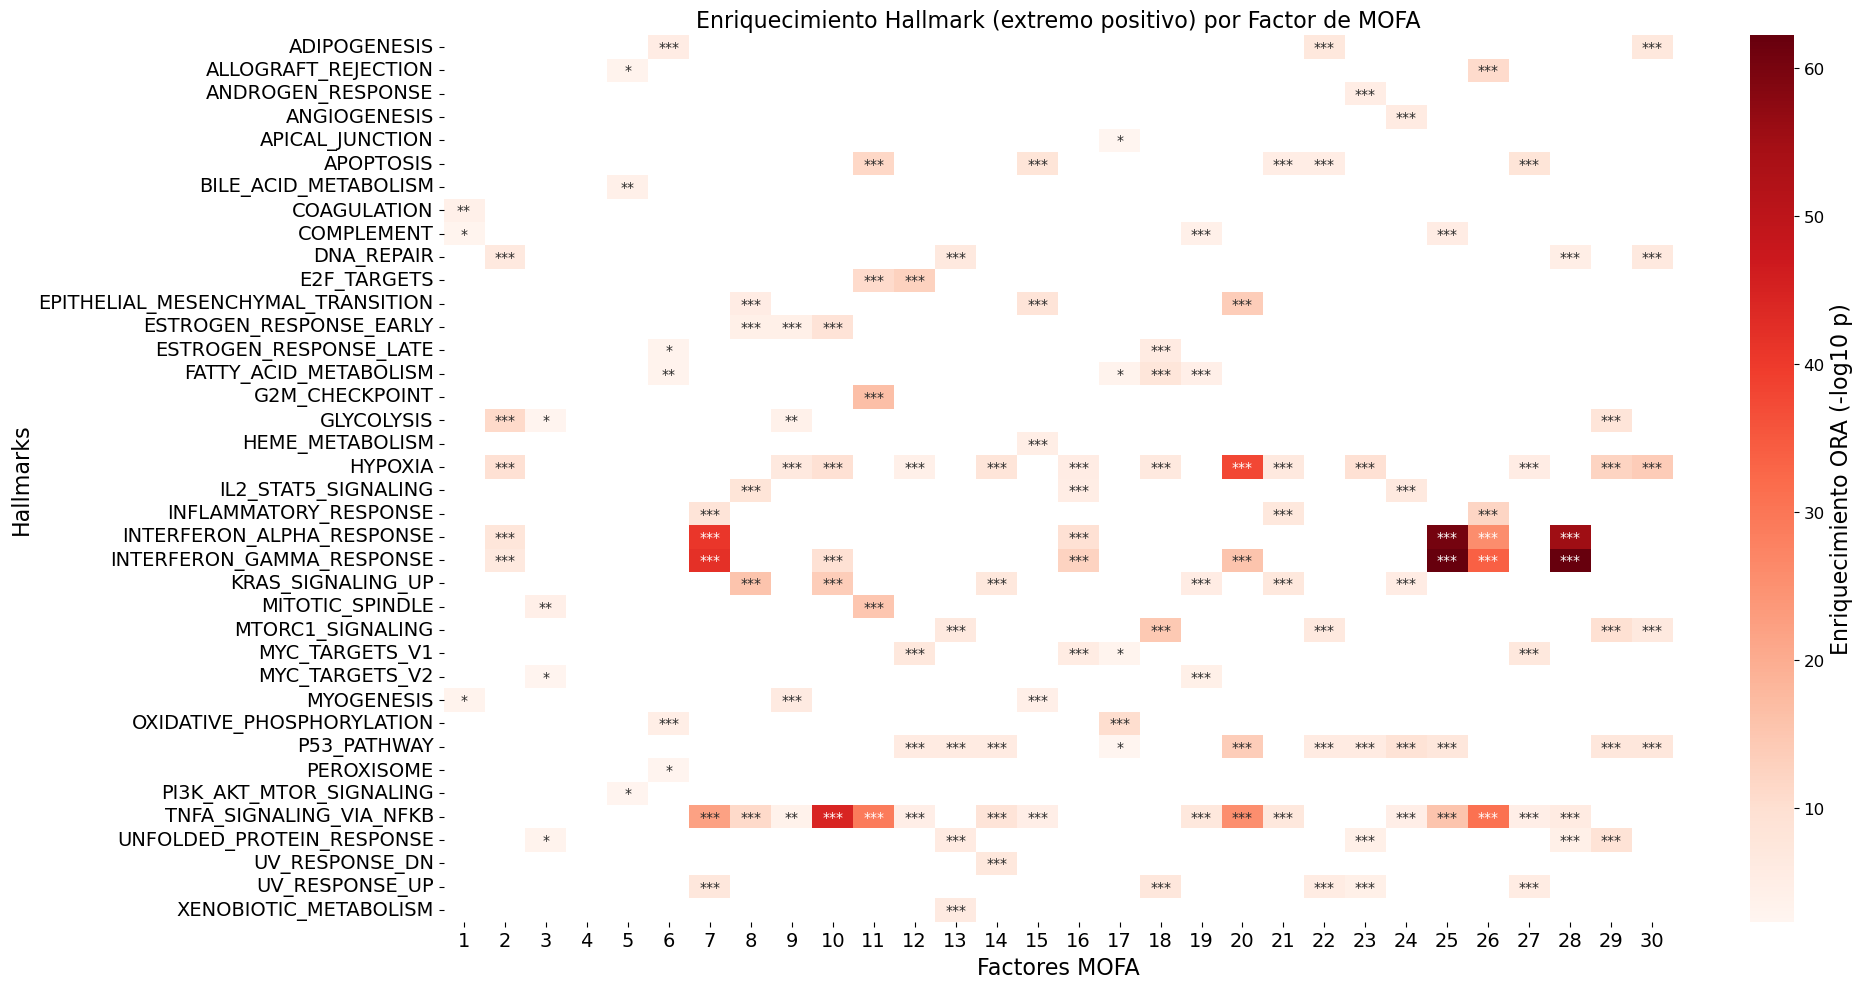

In [8]:
# quedarme solo con hallmarks presentes en algún factor
cols = mat_pos_sig.notna().any(axis=0)
mat_plot = mat_pos_sig.loc[:, cols]
padj_plot = mat_pos_padj.loc[:, cols].reindex(index=mat_plot.index, columns=mat_plot.columns)

# limpiar etiquetas: quitar "HALLMARK_" de los hallmarks y "Factor" de los factores
mat_plot = mat_plot.rename(
    columns=lambda c: c.replace("HALLMARK_", ""),   
    index=lambda f: f.replace("Factor", "").strip()  
)
padj_plot = padj_plot.rename(
    columns=lambda c: c.replace("HALLMARK_", ""),
    index=lambda f: f.replace("Factor", "").strip()
)

# matriz de asteriscos alineada celda a celda
annot_pos = padj_plot.applymap(get_stars)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    mat_plot.T,
    cmap='Reds',          # score ORA es siempre positivo, no divergente
    annot=annot_pos.T,
    fmt='',
    yticklabels=True,
    cbar_kws={'label': 'Enriquecimiento ORA (-log10 p)'},
    ax=ax
)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
cbar = ax.collections[0].colorbar
cbar.set_label('Enriquecimiento ORA (-log10 p)', size=16)
cbar.ax.tick_params(labelsize=12)
ax.set_title("Enriquecimiento Hallmark (extremo positivo) por Factor de MOFA", fontsize=16)
ax.set_xlabel("Factores MOFA", fontsize=16)
ax.set_ylabel("Hallmarks", fontsize=16)
plt.tight_layout()
plt.savefig(PATH_OUT + "heatmap_hallmark_pos.svg", format="svg", bbox_inches="tight")
plt.show()

/tmp/ipykernel_384372/3943594505.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pos = padj_plot.applymap(get_stars)


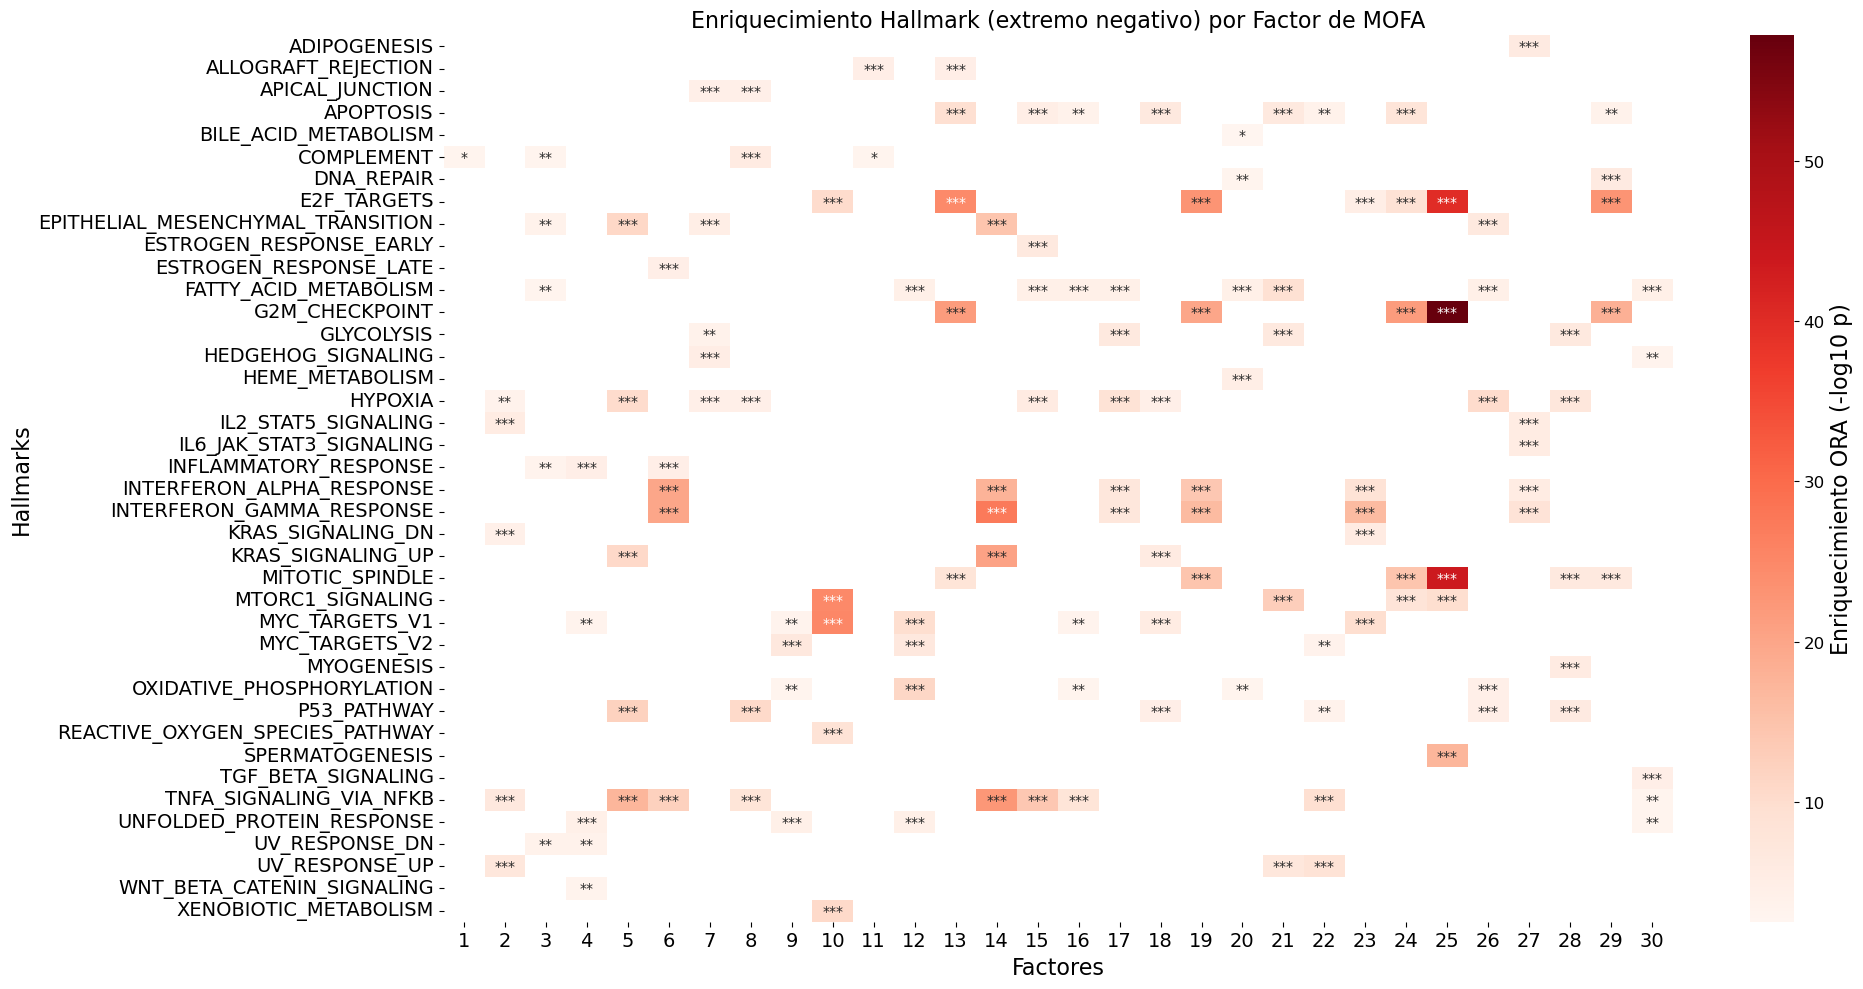

In [9]:
# quedarme solo con hallmarks presentes en algún factor
cols = mat_neg_sig.notna().any(axis=0)
mat_plot = mat_neg_sig.loc[:, cols]
padj_plot = mat_neg_padj.loc[:, cols].reindex(index=mat_plot.index, columns=mat_plot.columns)

# limpiar etiquetas: quitar "HALLMARK_" de los hallmarks y "Factor" de los factores
mat_plot = mat_plot.rename(
    columns=lambda c: c.replace("HALLMARK_", ""),   # hallmarks (van a filas tras .T)
    index=lambda f: f.replace("Factor", "").strip()  # factores (van a columnas tras .T)
)
padj_plot = padj_plot.rename(
    columns=lambda c: c.replace("HALLMARK_", ""),
    index=lambda f: f.replace("Factor", "").strip()
)
# matriz de asteriscos alineada celda a celda
annot_pos = padj_plot.applymap(get_stars)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    mat_plot.T,
    cmap='Reds',          # score ORA es siempre positivo, no divergente
    annot=annot_pos.T,
    fmt='',
    yticklabels=True,
    cbar_kws={'label': 'Enriquecimiento ORA (-log10 p)'},
    ax=ax
)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
cbar = ax.collections[0].colorbar
cbar.set_label('Enriquecimiento ORA (-log10 p)', size=16)
cbar.ax.tick_params(labelsize=12)
ax.set_title("Enriquecimiento Hallmark (extremo negativo) por Factor de MOFA", fontsize=16)
ax.set_xlabel("Factores", fontsize=16)
ax.set_ylabel("Hallmarks", fontsize=16)
plt.tight_layout()
plt.savefig(PATH_OUT +"heatmap_hallmark_neg.svg", format="svg", bbox_inches="tight")
plt.show()

In [10]:
import anndata as ad
import pandas as pd
import decoupler as dc

# --- Rutas ---
PATH_ADATA = "/home/miguel-agromayor-otero/Escritorio/TFM_datos/mofa_adata_30f.h5ad"
PATH_OUT_GRAF = "/home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/"
# --- Cargar datos ---
adata = ad.read_h5ad(PATH_ADATA)

# factores x muestras (usando los factor scores, no los pesos)
factor_scores = pd.DataFrame(
    adata.X,
    index=adata.obs['drug'],
    columns=adata.uns['mofa_weights_factors']
  ).T  # factores x muestras
factor_scores = factor_scores.T.groupby(level='drug').mean().T
net = adata.obs[['moa-fine','drug']].drop_duplicates().reset_index(drop=True)
net['weight'] = 1

acts_moa, pvals_moa = dc.run_ulm(mat=factor_scores, net=net, source='moa-fine', target='drug', weight='weight')

from statsmodels.stats.multitest import multipletests
import pandas as pd

# aplanar, corregir, y volver a dar forma de matriz
shape = pvals_moa.shape
padj = multipletests(pvals_moa.values.flatten(), method='fdr_bh')[1]
padj_moa = pd.DataFrame(padj.reshape(shape),
                            index=pvals_moa.index,
                            columns=pvals_moa.columns)

# usar padj en lugar de pvals para los asteriscos y el enmascarado

acts_moa_sig = acts_moa.copy()
acts_moa_sig[padj_moa > 0.05] = 0


/tmp/ipykernel_384372/2281249216.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  factor_scores = factor_scores.T.groupby(level='drug').mean().T


/tmp/ipykernel_384372/265739339.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drug_counts = adata.obs.groupby('moa-fine')['drug'].nunique()


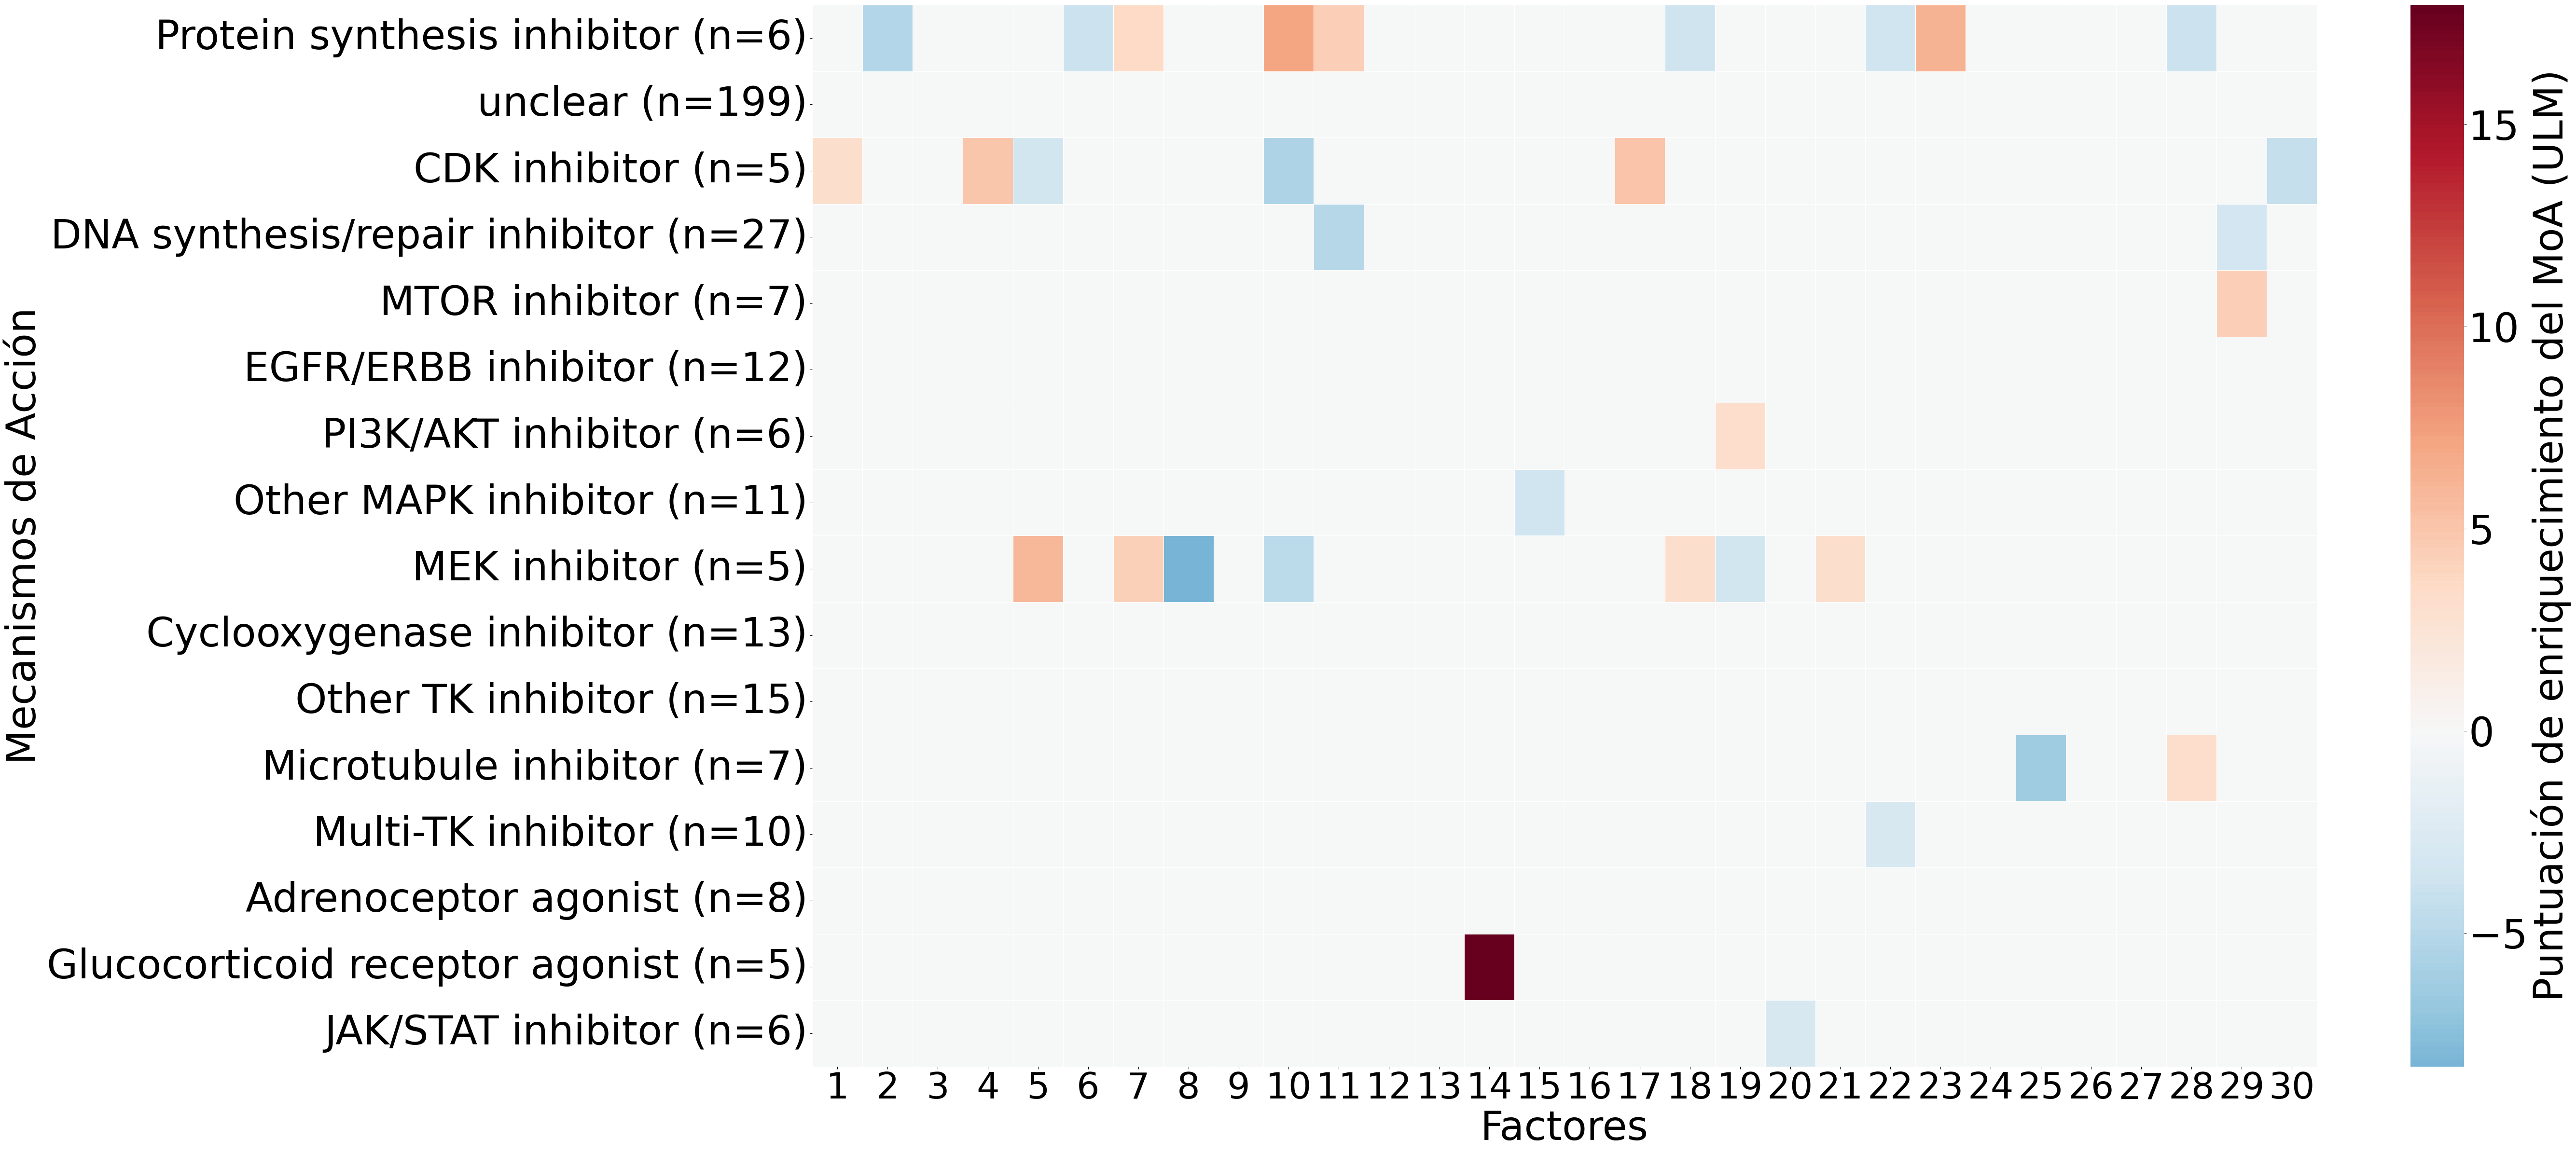

In [11]:
drug_counts = adata.obs.groupby('moa-fine')['drug'].nunique()

fig, ax = plt.subplots(figsize=(56, 24))
acts_moa_sig.index = acts_moa_sig.index.str.replace('Factor', '')

sns.heatmap(acts_moa_sig.T,
            cmap='RdBu_r',
            center=0,
            linewidths=0.5,
            yticklabels=True,
            xticklabels=True,
            )

new_ylabels = [f"{label.get_text()} (n={drug_counts.get(label.get_text(), 0)})" 
               for label in ax.get_yticklabels()]
ax.set_yticklabels(new_ylabels, fontsize=60)
cbar = ax.collections[0].colorbar
cbar.set_label('Puntuación de enriquecimiento del MoA (ULM)', size=60)
cbar.ax.tick_params(labelsize=60)
ax.tick_params(axis='x', labelsize=54)
plt.xlabel('Factores', size=60)
plt.ylabel('Mecanismos de Acción', size=60)
plt.tight_layout()
plt.savefig(PATH_OUT_GRAF + 'heatmap_moas.pdf', format="pdf", bbox_inches="tight")
plt.show()

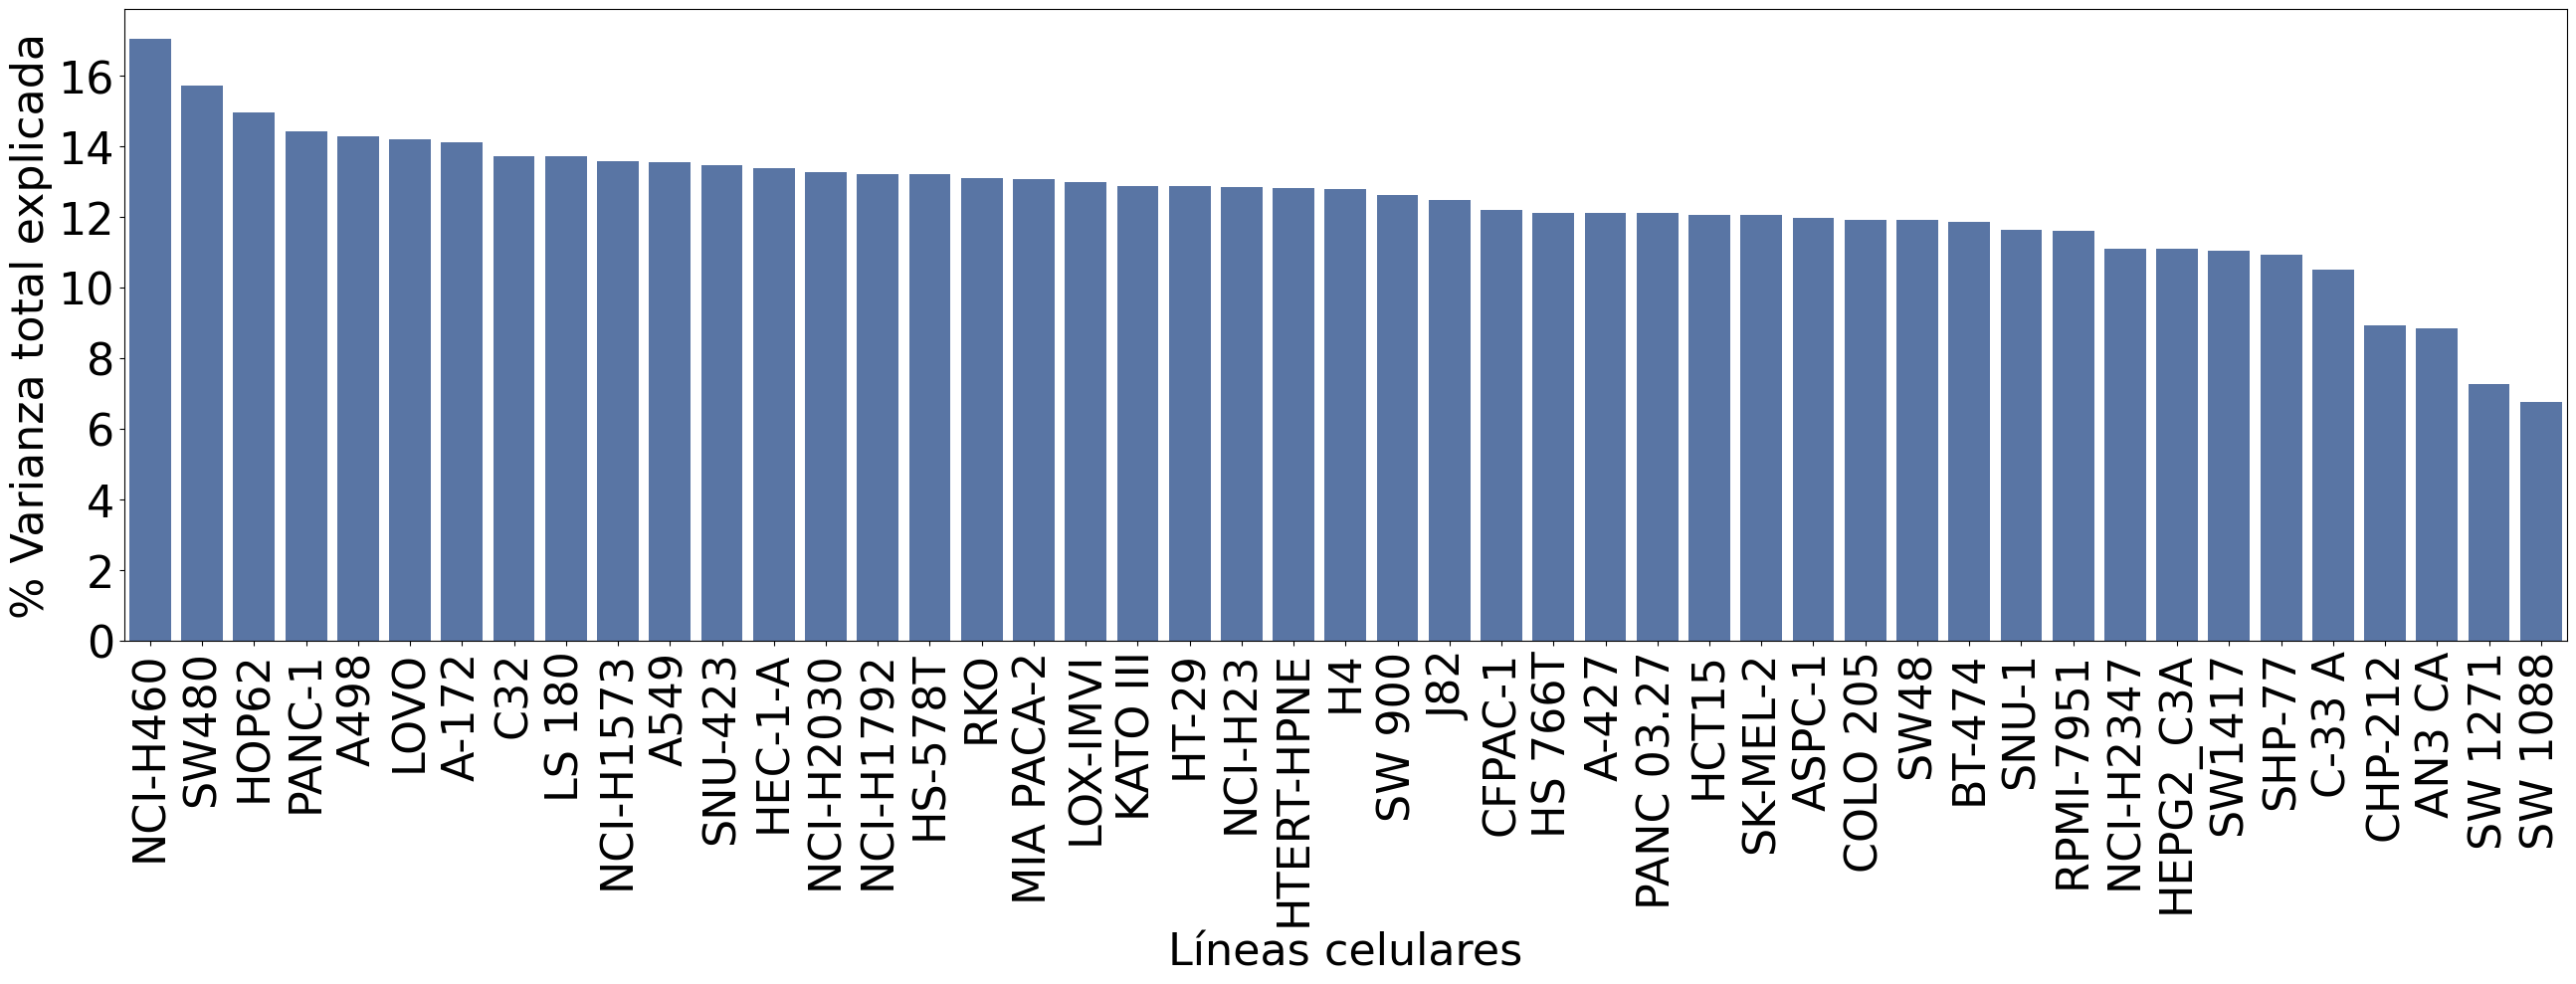

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
MOFA_MODEL = "/home/miguel-agromayor-otero/Escritorio/TFM_datos/modelo_mofa_30factors.hdf5"
model = mfx.mofa_model(MOFA_MODEL)
# suma de R² sobre factores dentro de cada (View, Group) → luego media sobre grupos
r2_total = (model.get_r2().groupby(["View", "Group"])["R2"].sum()   # varianza total por vista-grupo
              .groupby("View").mean()                    # promedio entre los 14 grupos
              .reset_index()
              .sort_values("R2", ascending=False))

plt.figure(figsize=(26,10))
sns.barplot(data=r2_total, x="View", y="R2",
            order=r2_total["View"], color="#4C72B0")
plt.xlabel("Líneas celulares", fontsize=32)
plt.ylabel("% Varianza total explicada", fontsize=32)
plt.xticks(rotation=90, fontsize=32)
plt.yticks(fontsize=32)
plt.tight_layout()
plt.savefig("/home/miguel-agromayor-otero/Escritorio/TFM_datos//Graficos/varianza_explicada.pdf",format = 'pdf' ,bbox_inches='tight')
plt.show()

In [15]:
PATH_BATCH = '/home/miguel-agromayor-otero/Descargas/drug_clustering/TFM_mao/resultados/technical_batch/'
# --- Cargar ANOVAs con corrección FDR ---
dfs_cov = {}
for cov in ['concentration', 'drug', 'moa_fine', 'plate']:
    df = pd.read_excel(PATH_BATCH + f'anova_{cov}.xlsx')
    _, pvals_fdr, _, _ = multipletests(df['P_Value'], method='fdr_bh')
    df[f'FDR_{cov}'] = pvals_fdr
    df = df.rename(columns={
        'F_Stat':   f'F_stat_{cov}',
        'P_Value':  f'pval_{cov}',
        'P_adj': f'pval_adj_{cov}',
        'Veredicto': f'sig_{cov}'
    })
    dfs_cov[cov] = df

df_covariates = (dfs_cov['concentration']
    .merge(dfs_cov['drug'],     on='Factor')
    .merge(dfs_cov['moa_fine'], on='Factor')
    .merge(dfs_cov['plate'],    on='Factor')
)

# --- Merge final ---
df_final = (df_genes
    .merge(df_resumen_progeny, on='Factor')
    .merge(df_hallmarks_ora,   on='Factor')
    .merge(df_covariates,      on='Factor')
)

print(f"Tabla final: {df_final.shape[0]} factores x {df_final.shape[1]} columnas")

# --- Guardar en Excel con pestañas temáticas ---
out = PATH_OUT + 'resumen_factores_completo.xlsx'

cols_genes    = ['Factor'] + [c for c in df_final.columns if 'Genes' in c]
cols_progeny  = ['Factor'] + [c for c in df_final.columns if 'PROGENy' in c]
cols_hallmark = ['Factor'] + [c for c in df_final.columns if 'Hallmark' in c]
cols_cov      = ['Factor'] + [c for c in df_final.columns if any(x in c for x in ['F_', 'pval_', 'FDR_', 'sig_'])]

with pd.ExcelWriter(out, engine='openpyxl') as writer:
    df_final.to_excel(writer,               sheet_name='Resumen_completo', index=False)
    df_final[cols_genes].to_excel(writer,   sheet_name='Top_Genes',        index=False)
    df_final[cols_progeny].to_excel(writer, sheet_name='PROGENy',          index=False)
    df_final[cols_hallmark].to_excel(writer,sheet_name='Hallmarks',        index=False)
    df_final[cols_cov].to_excel(writer,     sheet_name='Covariates',       index=False)

print(f"Guardado en {out}")

Tabla final: 30 factores x 27 columnas
Guardado en /home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/resumen_factores_completo.xlsx
